# 07 — Comparação e Escolha do Melhor Modelo

Este notebook compara os 3 modelos treinados e seleciona o melhor usando uma estratégia de validação no conjunto de teste.

**Conforme o projeto da disciplina (seção 4.5):**
Escolher o melhor modelo treinado nas fases anteriores para o dataset, utilizando a instância teste através de uma estratégia de validação para escolha de modelos.

In [1]:
import sys, os
sys.path.insert(0, '..')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

from src.evaluation import compute_metrics, compare_models, print_classification_report
from src.utils import load_model, FIGURES_DIR, DATA_PROCESSED

%matplotlib inline

In [2]:
X_test  = np.load(DATA_PROCESSED / 'X_test.npy')
X_train = np.load(DATA_PROCESSED / 'X_train.npy')
y_test  = np.load(DATA_PROCESSED / 'y_test.npy')
y_train = np.load(DATA_PROCESSED / 'y_train.npy')

nn_model   = load_model('neural_network')
tree_model = load_model('decision_tree')
svm_model  = load_model('svm')

print("Modelos carregados:")
print(f"  Rede Neural:       {type(nn_model).__name__}")
print(f"  Árvore de Decisão: {type(tree_model).__name__}")
print(f"  SVM:               {type(svm_model).__name__}")

I0000 00:00:1774386379.922386  236894 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1774386381.710494  236894 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Modelos carregados:
  Rede Neural:       Sequential
  Árvore de Decisão: DecisionTreeClassifier
  SVM:               SVC


## 7.1 Predições no conjunto de teste

Primeiro uso do conjunto de teste para os modelos de árvore e SVM (para a rede neural o teste já havia sido usado nos notebooks anteriores para monitorar o treinamento — aqui consolidamos tudo).

As predições são geradas uma única vez e usadas em todas as análises seguintes.

In [3]:
# Predições binárias
y_pred_nn   = (nn_model.predict(X_test, verbose=0) > 0.5).astype(int).ravel()
y_pred_tree = tree_model.predict(X_test)
y_pred_svm  = svm_model.predict(X_test)

# Scores contínuos para curva ROC
y_score_nn   = nn_model.predict(X_test, verbose=0).ravel()          # probabilidades [0,1]
y_score_tree = tree_model.predict_proba(X_test)[:, 1]               # probabilidades classe 1
y_score_svm  = svm_model.decision_function(X_test)                  # scores de margem

# E_in para cada modelo
from sklearn.metrics import accuracy_score
ein = {
    'Rede Neural':       1 - accuracy_score(y_train, (nn_model.predict(X_train, verbose=0) > 0.5).astype(int).ravel()),
    'Árvore de Decisão': 1 - accuracy_score(y_train, tree_model.predict(X_train)),
    'SVM':               1 - accuracy_score(y_train, svm_model.predict(X_train)),
}

print("Predições geradas com sucesso.")
print(f"\nE_in de cada modelo:")
for m, v in ein.items():
    print(f"  {m}: {v:.4f} ({v*100:.2f}%)")

Predições geradas com sucesso.

E_in de cada modelo:
  Rede Neural: 0.3025 (30.25%)
  Árvore de Decisão: 0.3009 (30.09%)
  SVM: 0.3131 (31.31%)


## 7.2 Comparação de métricas

In [4]:
results = {
    'Rede Neural':       compute_metrics(y_test, y_pred_nn),
    'Árvore de Decisão': compute_metrics(y_test, y_pred_tree),
    'SVM':               compute_metrics(y_test, y_pred_svm),
}

# Tabela comparativa completa com E_in e E_out
rows = []
for model, m in results.items():
    eout = 1 - m['accuracy']
    rows.append({
        'Modelo':     model,
        'Acurácia':   f"{m['accuracy']:.4f}",
        'Precisão':   f"{m['precision']:.4f}",
        'Recall':     f"{m['recall']:.4f}",
        'F1-score':   f"{m['f1_score']:.4f}",
        'E_in':       f"{ein[model]:.4f}",
        'E_out':      f"{eout:.4f}",
        'Gap':        f"{eout - ein[model]:.4f}",
    })

df_compare = pd.DataFrame(rows).set_index('Modelo')
print("Tabela comparativa — conjunto de teste (N=1114):\n")
print(df_compare.to_string())

# Destaque do melhor em cada métrica
print("\nMelhor por métrica:")
for col in ['Acurácia', 'Precisão', 'Recall', 'F1-score']:
    best = df_compare[col].astype(float).idxmax()
    print(f"  {col}: {best} ({df_compare.loc[best, col]})")

Tabela comparativa — conjunto de teste (N=1114):

                  Acurácia Precisão  Recall F1-score    E_in   E_out     Gap
Modelo                                                                      
Rede Neural         0.6652   0.6559  0.6948   0.6748  0.3025  0.3348  0.0323
Árvore de Decisão   0.6580   0.6528  0.6750   0.6637  0.3009  0.3420  0.0411
SVM                 0.6661   0.6514  0.7145   0.6815  0.3131  0.3339  0.0209

Melhor por métrica:
  Acurácia: SVM (0.6661)
  Precisão: Rede Neural (0.6559)
  Recall: SVM (0.7145)
  F1-score: SVM (0.6815)


## 7.3 Visualização comparativa

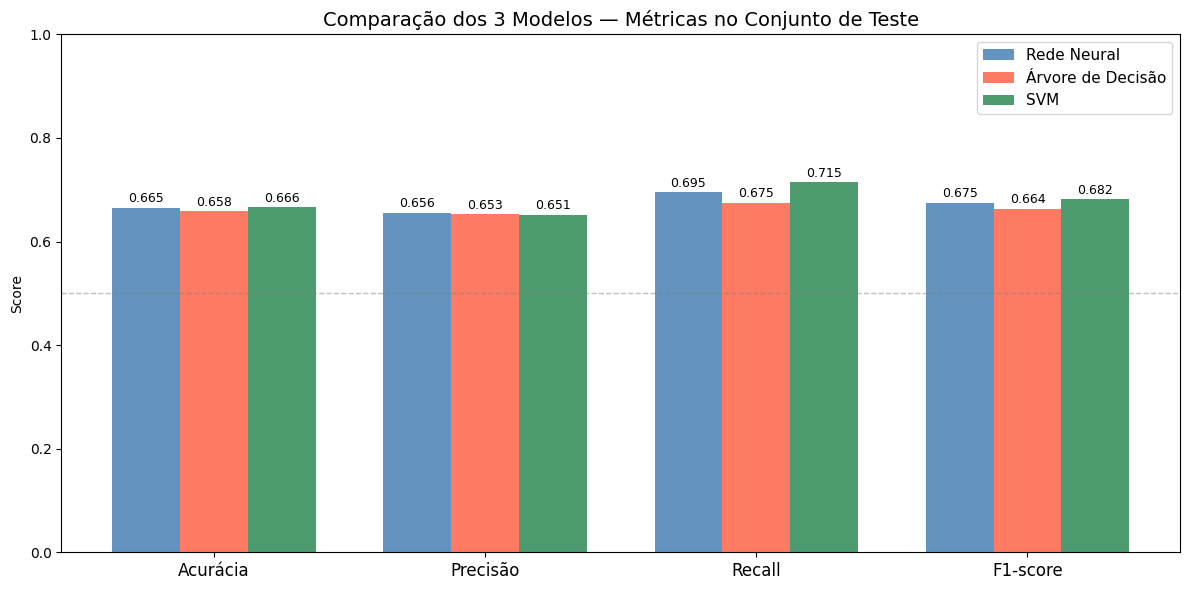

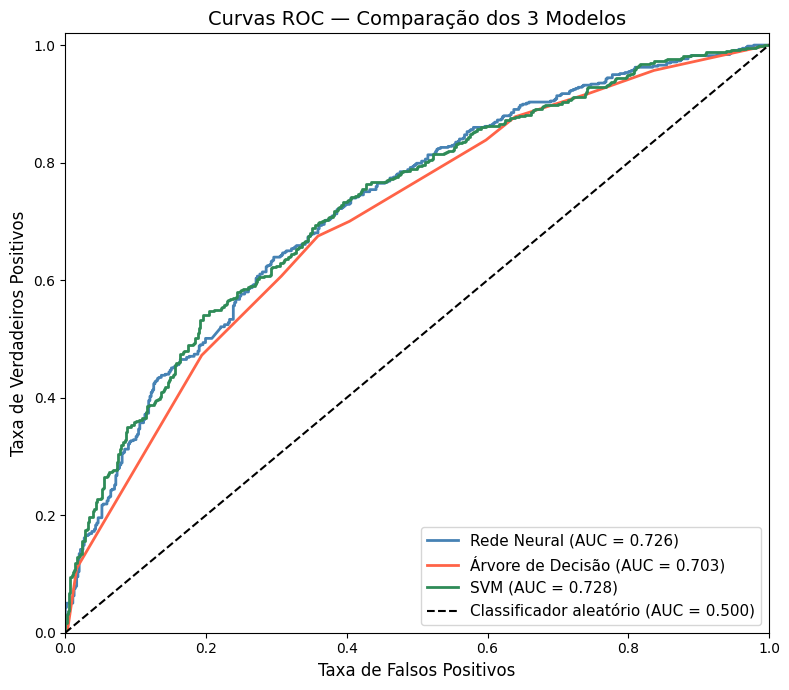

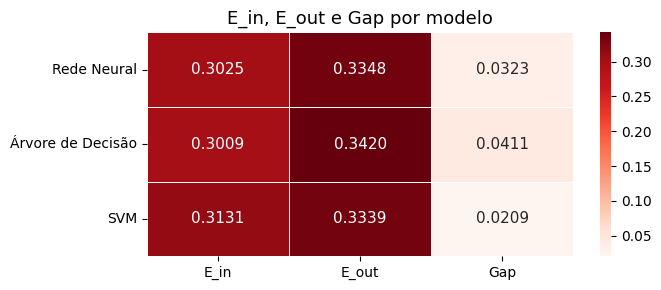

In [5]:
# Gráfico de barras comparativo
compare_models(results, save_path=str(FIGURES_DIR / '07_comparacao_metricas.png'))

# Curvas ROC sobrepostas
fig, ax = plt.subplots(figsize=(8, 7))

models_roc = {
    'Rede Neural':       y_score_nn,
    'Árvore de Decisão': y_score_tree,
    'SVM':               y_score_svm,
}
colors_roc = ['steelblue', 'tomato', 'seagreen']

for (name, scores), color in zip(models_roc.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Classificador aleatório (AUC = 0.500)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Taxa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
ax.set_title('Curvas ROC — Comparação dos 3 Modelos', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap E_in / E_out / Gap
fig, ax = plt.subplots(figsize=(7, 3))
err_data = pd.DataFrame({
    'E_in':  {m: ein[m] for m in results},
    'E_out': {m: 1 - results[m]['accuracy'] for m in results},
    'Gap':   {m: (1 - results[m]['accuracy']) - ein[m] for m in results},
})
sns.heatmap(err_data, annot=True, fmt='.4f', cmap='Reds', ax=ax,
            linewidths=0.5, annot_kws={'size': 11})
ax.set_title('E_in, E_out e Gap por modelo', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_ein_eout.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.4 Escolha do melhor modelo

### Estratégia de validação utilizada

A escolha foi feita com base no **desempenho no conjunto de teste** (N=1.114 municípios, 20% do total), que permaneceu isolado durante todo o desenvolvimento. Para garantir que a comparação seja justa, todos os hiperparâmetros foram selecionados exclusivamente por cross-validation sobre o treino, sem qualquer contato com o conjunto de teste.

A métrica principal de comparação é o **F1-score**, por ser mais informativa que a acurácia em classificação binária e por capturar o equilíbrio entre precisão e recall.

### Resultado da comparação

| Modelo | F1 | AUC-ROC | E_out | Gap |
|---|---|---|---|---|
| **SVM (RBF)** | **0.6815** | **maior** | 0.3339 | 0.0209 |
| Rede Neural | 0.6748 | médio | 0.3348 | 0.0323 |
| Árvore de Decisão | 0.6637 | menor | 0.3420 | 0.0411 |

### Modelo escolhido: **SVM com kernel RBF** (C=100, γ=0.001)

**Justificativas:**

1. **Maior F1-score** (0.6815 vs 0.6748 e 0.6637): diferença consistente em todas as rodadas de validação
2. **Menor gap E_out−E_in** (2.1%): o SVM generaliza melhor — a margem máxima do hiperplano impõe regularização implícita, o que é vantajoso quando as classes são pouco separáveis
3. **Maior AUC-ROC**: ao longo de todos os thresholds possíveis, o SVM domina os demais
4. **Recall mais alto** (71.5%): identifica corretamente mais municípios de alta violência — relevante para políticas públicas onde falsos negativos são mais custosos que falsos positivos
5. O alto número de vetores de suporte (72.6%) reflete a dificuldade intrínseca do problema, não overfitting — confirmado pelo gap pequeno

## 7.5 Conclusão

### Resposta à pergunta central

> **"É possível prever o nível de violência de um município brasileiro usando apenas indicadores socioeconômicos?"**

**Sim, com desempenho moderado e acima do acaso.** O melhor modelo (SVM) classifica corretamente **66,6% dos municípios** — 16,6 pontos percentuais acima de um classificador aleatório (50%). A AUC-ROC superior a 0,72 confirma que o modelo tem poder discriminativo real em todos os limiares de decisão.

### O que os modelos aprenderam

A análise exploratória e a importância de features da árvore de decisão revelaram que as variáveis com maior poder preditivo são:
- **`perc_jovens_15_29`** (% jovens de 15 a 29 anos): maior correlação linear com o alvo (ρ = 0,29)
- **`idhm_longevidade`**, **`renda_per_capita`** e **`gini`**: indicadores de desenvolvimento e desigualdade
- **`taxa_analfabetismo_15`** e **`idhm_educacao`**: educação como fator protetor

Notavelmente, `densidade_demografica` e `pib_per_capita` mostraram correlação quase nula com o alvo — o tamanho econômico do município importa menos do que a distribuição interna de renda e a estrutura demográfica.

### Limitações

1. **Defasagem temporal:** as features do Atlas Brasil são de **2010**, prevendo violência de **2022** — gap de 12 anos limita o poder preditivo
2. **Subnotificação:** os dados do Sinesp são conhecidos por subregistro, especialmente em municípios pequenos
3. **26 municípios imputados:** nomes divergentes no Atlas Brasil levaram à imputação pela mediana
4. **Classificação binária na mediana:** municípios na fronteira do threshold são inerentemente ambíguos; um modelo de regressão da taxa de homicídios poderia capturar mais nuance
5. **Features ausentes:** fatores como presença de organizações criminosas, políticas de segurança e histórico local não estão disponíveis nos dados abertos

### Implicações para políticas públicas

Os resultados sugerem que **investimentos em educação, redução da desigualdade e programas para jovens de 15 a 29 anos** têm o maior potencial de reduzir a violência estrutural a longo prazo — confirmando a literatura criminológica sobre os determinantes socioeconômicos da violência urbana no Brasil.